### [이미지 내 객체의 윤곽선/외곽선 추출 : 컨투어 ] <hr>
- 윤곽선/외곽선에 해당하는 좌표값(즉, 픽셀들) 반환
- 좌표 개수를 줄이기 위한 매개변수 설정 필요 ===> 메모리 / 연산 고려

In [2]:
import cv2
import numpy as np
import sys
sys.path.append('..')
from cv_utils import *

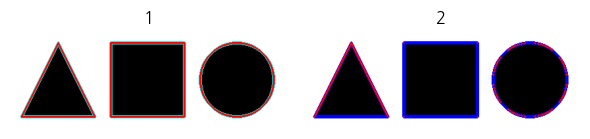

In [32]:
img = cv2.imread('../Data/images/shapes.png')
img2 = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, imthres = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
contour, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[-2:]
contour2, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[-2:]

cv2.drawContours(img, contour, -1, (0,255,255), 4)
cv2.drawContours(img2, contour2, -1, (0,0,255), 4)

for i in contour:
    for j in i: cv2.circle(img, tuple(j[0]), 1, (255,0,0), -1)

for i in contour2:
    for j in i: cv2.circle(img2, tuple(j[0]), 1, (255,0,0), -1)

printPlots(1,2, [1,2], [img, img2])

### [이미지 내 객체의 윤곽선/외곽선 추출 : 컨투어 ] <hr>
- 계층구조
    * 윤곽선 정보 기반 이미지/영상 내의 객체의 구조
    * 표현 형태 : [next_idx previdx child_idx parent_idx]
    * -1 의미 : 존재하진 않음

3 [[[ 1 -1 -1 -1]
  [ 2  0 -1 -1]
  [-1  1 -1 -1]]]
6 [[[ 2 -1  1 -1]
  [-1 -1 -1  0]
  [ 4  0  3 -1]
  [-1 -1 -1  2]
  [-1  2  5 -1]
  [-1 -1 -1  4]]]


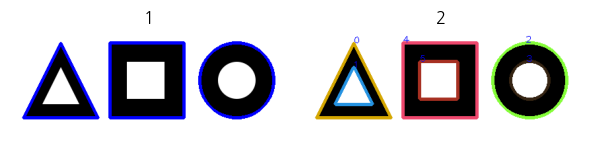

In [47]:
img = cv2.imread('../Data/images/shapes_donut.png')
img2 = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, imthres = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

contour, hierarchy = cv2.findContours(imthres, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[-2:]
print(len(contour), hierarchy)

contour2, hierarchy = cv2.findContours(imthres, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)[-2:]
print(len(contour2), hierarchy)

cv2.drawContours(img, contour, -1, (0,0,255), 4)
# cv2.drawContours(img2, contour2, -1, (0,0,255), 4)

for idx, cont in enumerate(contour2):
    color = [int(i) for i in np.random.randint(0,255, 3)]
    cv2.drawContours(img2, contour2, idx, color, 3)
    cv2.putText(img2, str(idx), tuple(cont[0][0]), cv2.FONT_HERSHEY_PLAIN, 1, (0,0,255))

printPlots(1,2, [1,2], [img, img2])